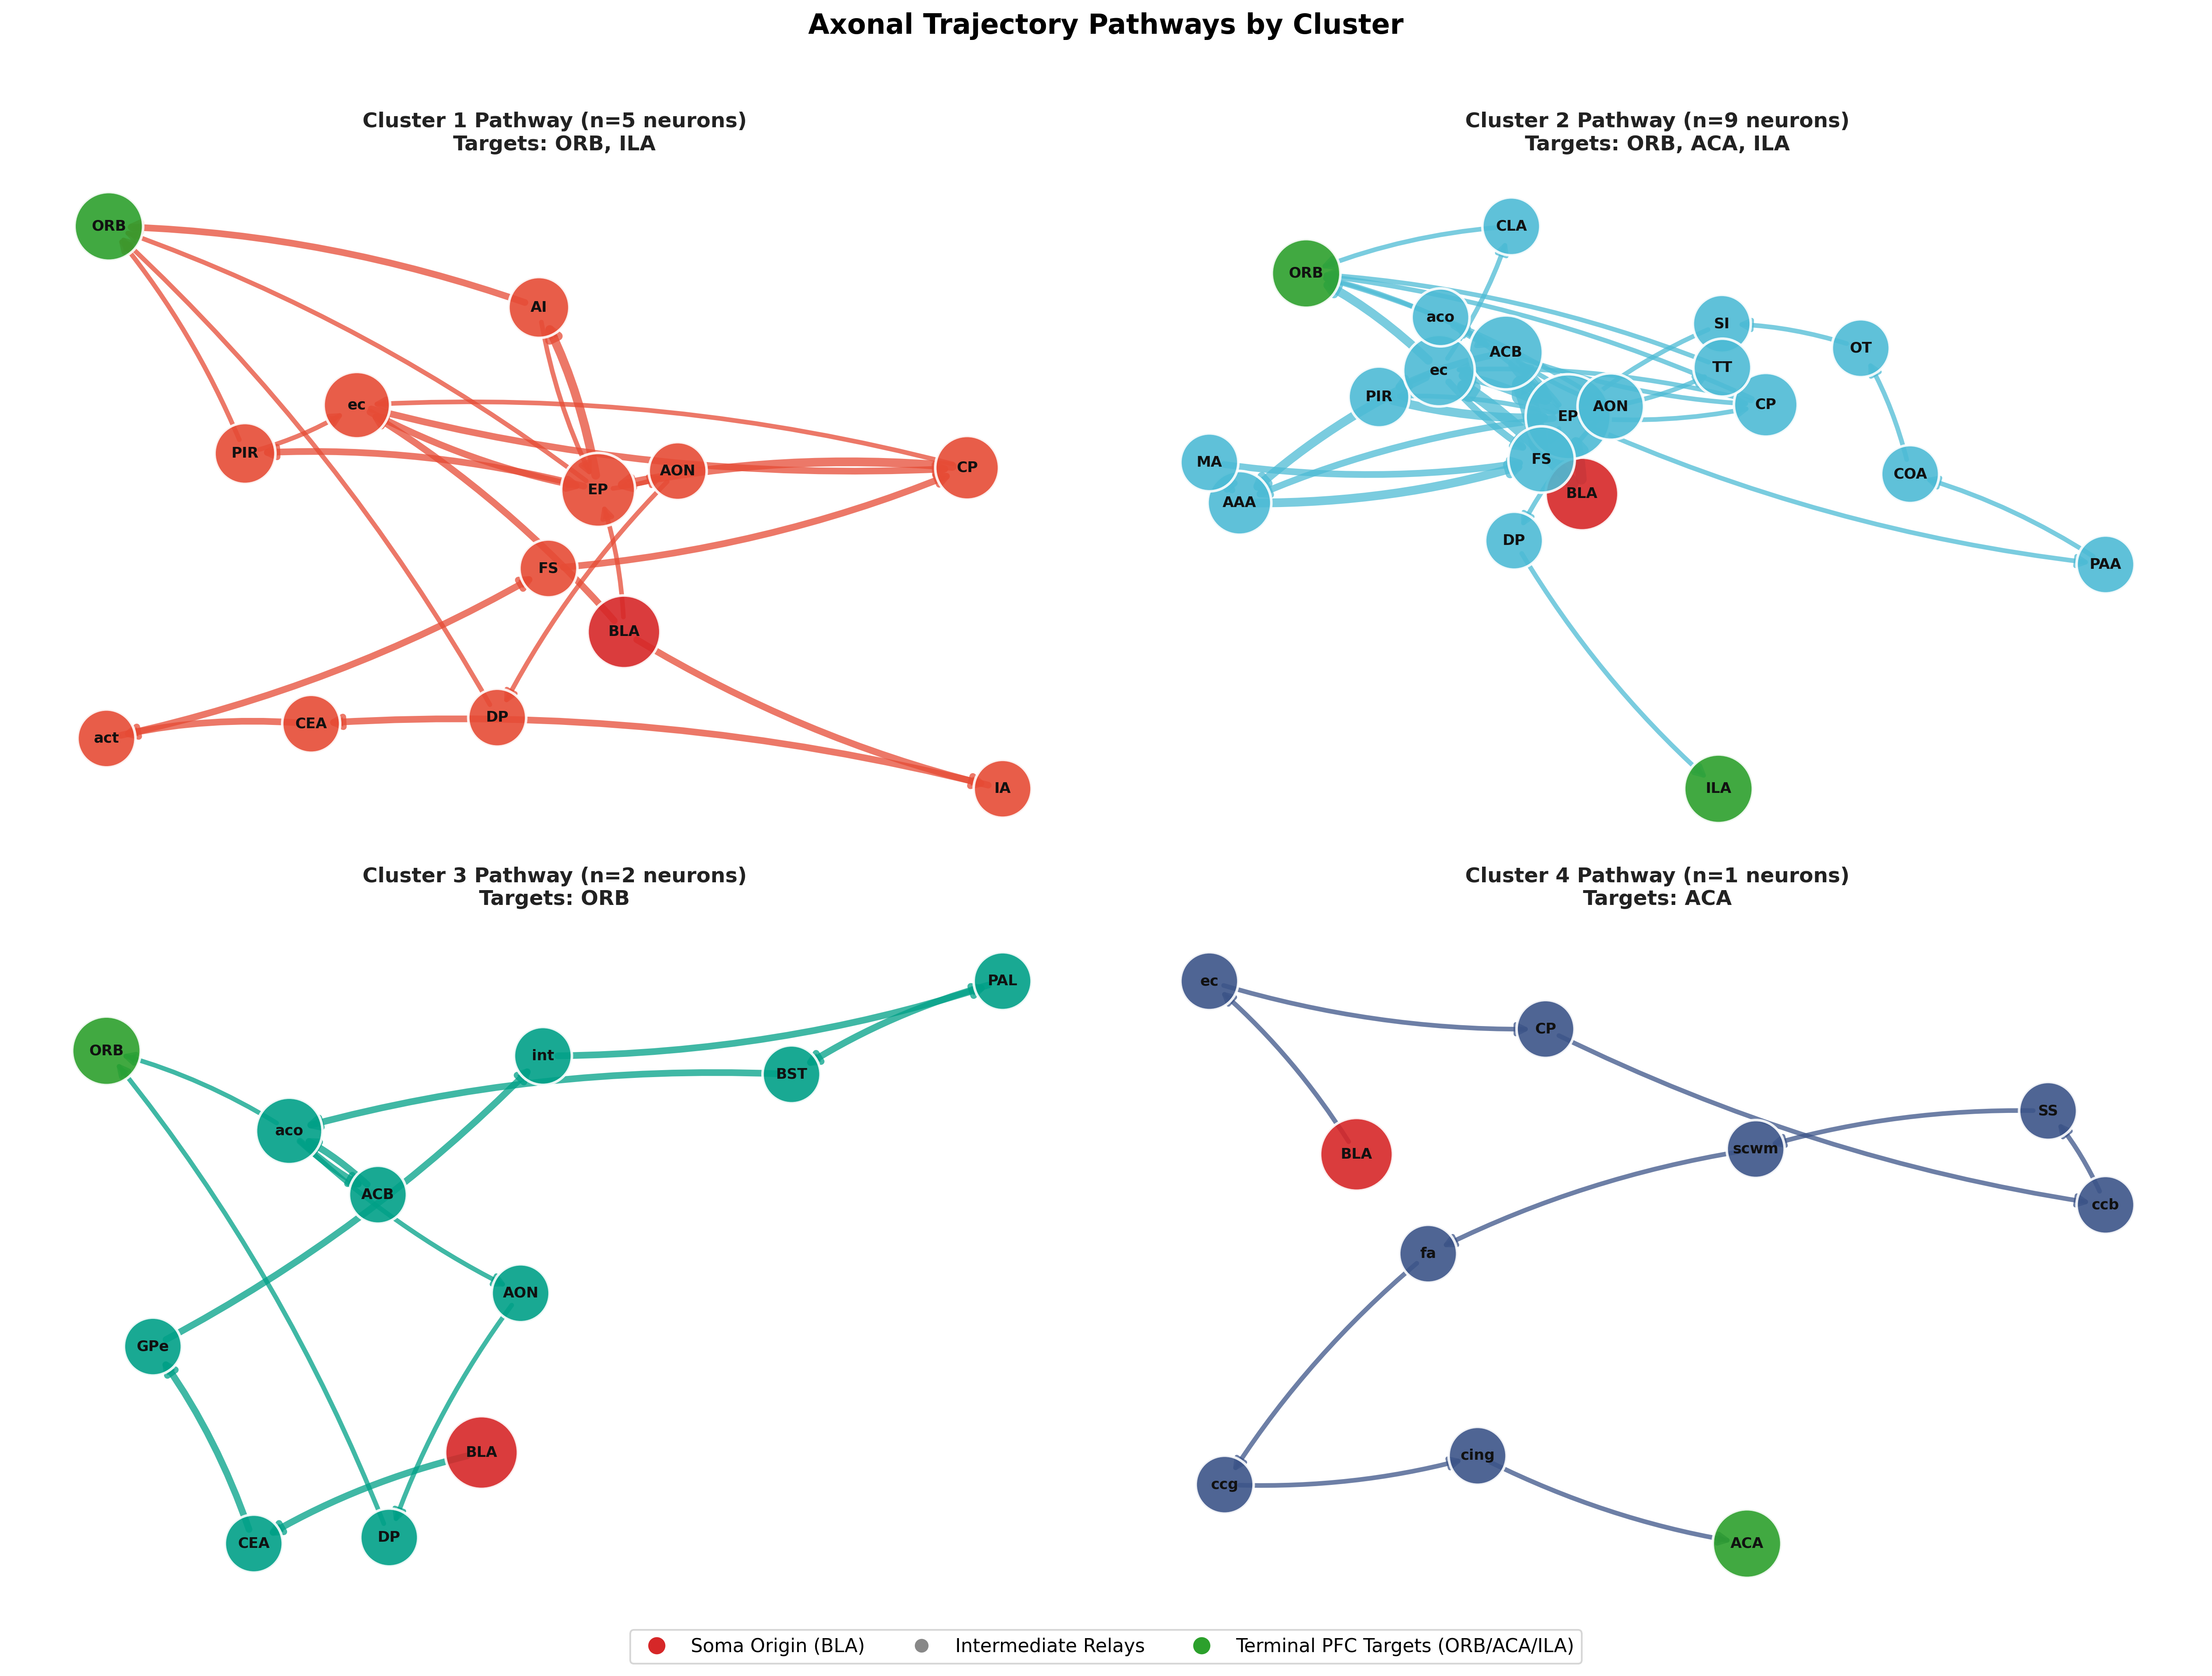

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import io

# 1. 载入数据
data = """neurons	cluster	Terminal_Group	Truncated_PFC_Trajectory
251034_001_Vglut1_PFC_0	1	ORB	BLA -> EP -> PIR -> ec -> EP -> AI -> ORB
251034_003_Vglut1_PFC_1	1	ORB	BLA -> ec -> CP -> EP -> ORB
251034_003_Vglut1_PFC_2	2	ORB	BLA -> EP -> FS -> ACB -> CP -> ORB
251034_004_Vglut1_PFC_3	2	ORB	BLA -> EP -> PIR -> EP -> PAA -> COA -> OT -> SI -> EP -> CP -> ec -> ORB
251034_010_Vglut1_PFC_4	2	ORB	BLA -> ec -> AAA -> FS -> ACB -> EP -> AON -> ORB
251034_010_Vglut1_PFC_5	2	ORB	BLA -> ec -> AAA -> FS -> ACB -> EP -> AON -> TT -> ORB
251034_010_Vglut1_PFC_6	2	ORB	BLA -> ec -> AAA -> FS -> ACB -> EP -> ec -> ORB
251039_020_Vglut1_PFC_7	2	ACA	BLA -> ec -> FS -> ACB -> EP -> ACB -> ORB
251039_020_Vglut1_PFC_8	2	ILA	BLA -> ec -> FS -> ACB -> EP -> aco -> ACB -> AON -> DP -> ILA
251039_021_Vglut1_PFC_10	3	ORB	BLA -> CEA -> GPe -> int -> PAL -> BST -> aco -> ACB -> aco -> AON -> DP -> ORB
251039_021_Vglut1_PFC_9	3	ORB	BLA -> CEA -> GPe -> int -> PAL -> BST -> aco -> ACB -> aco -> ORB
251039_029_Vglut1_PFC_11	4	ACA	BLA -> ec -> CP -> ccb -> SS -> scwm -> fa -> ccg -> cing -> ACA
251039_029_Vglut1_PFC_12	1	ORB	BLA -> IA -> CEA -> act -> FS -> CP -> EP -> AI -> ORB
251039_029_Vglut1_PFC_13	1	ORB	BLA -> IA -> CEA -> act -> FS -> CP -> EP -> PIR -> ORB
251039_029_Vglut1_PFC_14	2	ORB	BLA -> EP -> AAA -> MA -> FS -> ACB -> PIR -> EP -> ec -> ORB
251039_029_Vglut1_PFC_15	2	ORB	BLA -> EP -> AAA -> MA -> FS -> ACB -> PIR -> EP -> ec -> CLA -> ORB
251039_033_Vglut1_PFC_16	1	ILA	BLA -> ec -> CP -> ec -> EP -> AI -> EP -> AON -> DP -> ORB"""

df = pd.read_csv(io.StringIO(data), sep='\t')

# 2. 先构建全局全图，计算统一的节点坐标（确保4个子图中的脑区位置保持一致）
G_global = nx.DiGraph()
for _, row in df.iterrows():
    nodes = [n.strip() for n in row['Truncated_PFC_Trajectory'].split('->') if n.strip()]
    for u, v in zip(nodes[:-1], nodes[1:]):
        G_global.add_edge(u, v)

# 固定全局坐标
global_pos = nx.spring_layout(G_global, k=1.3, seed=42, iterations=150)

# 3. 颜色与节点类别配置
cluster_colors = {
    1: '#E64B35',  # 红色系
    2: '#4DBBD5',  # 蓝色系
    3: '#00A087',  # 绿色系
    4: '#3C5488'   # 靛青色系
}
start_nodes = {'BLA'}
terminal_targets = {'ORB', 'ACA', 'ILA'}

# 4. 创建 2x2 子图画布
fig, axes = plt.subplots(2, 2, figsize=(18, 14), dpi=300)
axes = axes.flatten()

for idx, cluster_id in enumerate(sorted(df['cluster'].unique())):
    ax = axes[idx]
    sub_df = df[df['cluster'] == cluster_id]
    
    # 构建当前 Cluster 的子图
    G_sub = nx.DiGraph()
    for _, row in sub_df.iterrows():
        nodes = [n.strip() for n in row['Truncated_PFC_Trajectory'].split('->') if n.strip()]
        for u, v in zip(nodes[:-1], nodes[1:]):
            if G_sub.has_edge(u, v):
                G_sub[u][v]['weight'] += 1
            else:
                G_sub.add_edge(u, v, weight=1)
                
    # 提取子图在全局中的位置
    sub_pos = {n: global_pos[n] for n in G_sub.nodes()}
    
    # 设置节点颜色
    node_colors = []
    node_sizes = []
    for node in G_sub.nodes():
        if node in start_nodes:
            node_colors.append('#D62728')  # 统一红色标出起点 BLA
            node_sizes.append(1800)
        elif node in terminal_targets:
            node_colors.append('#2CA02C')  # 统一绿色标出终点 PFC
            node_sizes.append(1600)
        else:
            node_colors.append(cluster_colors[cluster_id])
            node_sizes.append(900 + G_sub.degree(node) * 120)

    # 计算边权重
    edge_weights = [G_sub[u][v]['weight'] for u, v in G_sub.edges()]
    edge_widths = [1.5 + 1.2 * w for w in edge_weights]

    # 绘制
    nx.draw_networkx_nodes(G_sub, sub_pos, ax=ax, node_color=node_colors, 
                           node_size=node_sizes, alpha=0.9, edgecolors='white', linewidths=1.5)
    
    nx.draw_networkx_edges(G_sub, sub_pos, ax=ax, width=edge_widths, 
                           edge_color=cluster_colors[cluster_id], alpha=0.75,
                           arrows=True, arrowsize=14, arrowstyle='-|>', 
                           connectionstyle='arc3,rad=0.08')
    
    nx.draw_networkx_labels(G_sub, sub_pos, ax=ax, font_size=8.5, 
                            font_weight='bold', font_color='#111111')
    
    # 统计信息作为副标题
    n_neurons = len(sub_df)
    targets = ", ".join(sub_df['Terminal_Group'].unique())
    ax.set_title(f"Cluster {cluster_id} Pathway (n={n_neurons} neurons)\nTargets: {targets}", 
                 fontsize=12, fontweight='bold', color='#222222', pad=10)
    ax.axis('off')

# 5. 添加总图例
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Soma Origin (BLA)', 
               markerfacecolor='#D62728', markersize=11),
    plt.Line2D([0], [0], marker='o', color='w', label='Intermediate Relays', 
               markerfacecolor='#888888', markersize=9),
    plt.Line2D([0], [0], marker='o', color='w', label='Terminal PFC Targets (ORB/ACA/ILA)', 
               markerfacecolor='#2CA02C', markersize=11)
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, frameon=True, fontsize=11, bbox_to_anchor=(0.5, 0.02))

plt.suptitle('Axonal Trajectory Pathways by Cluster', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

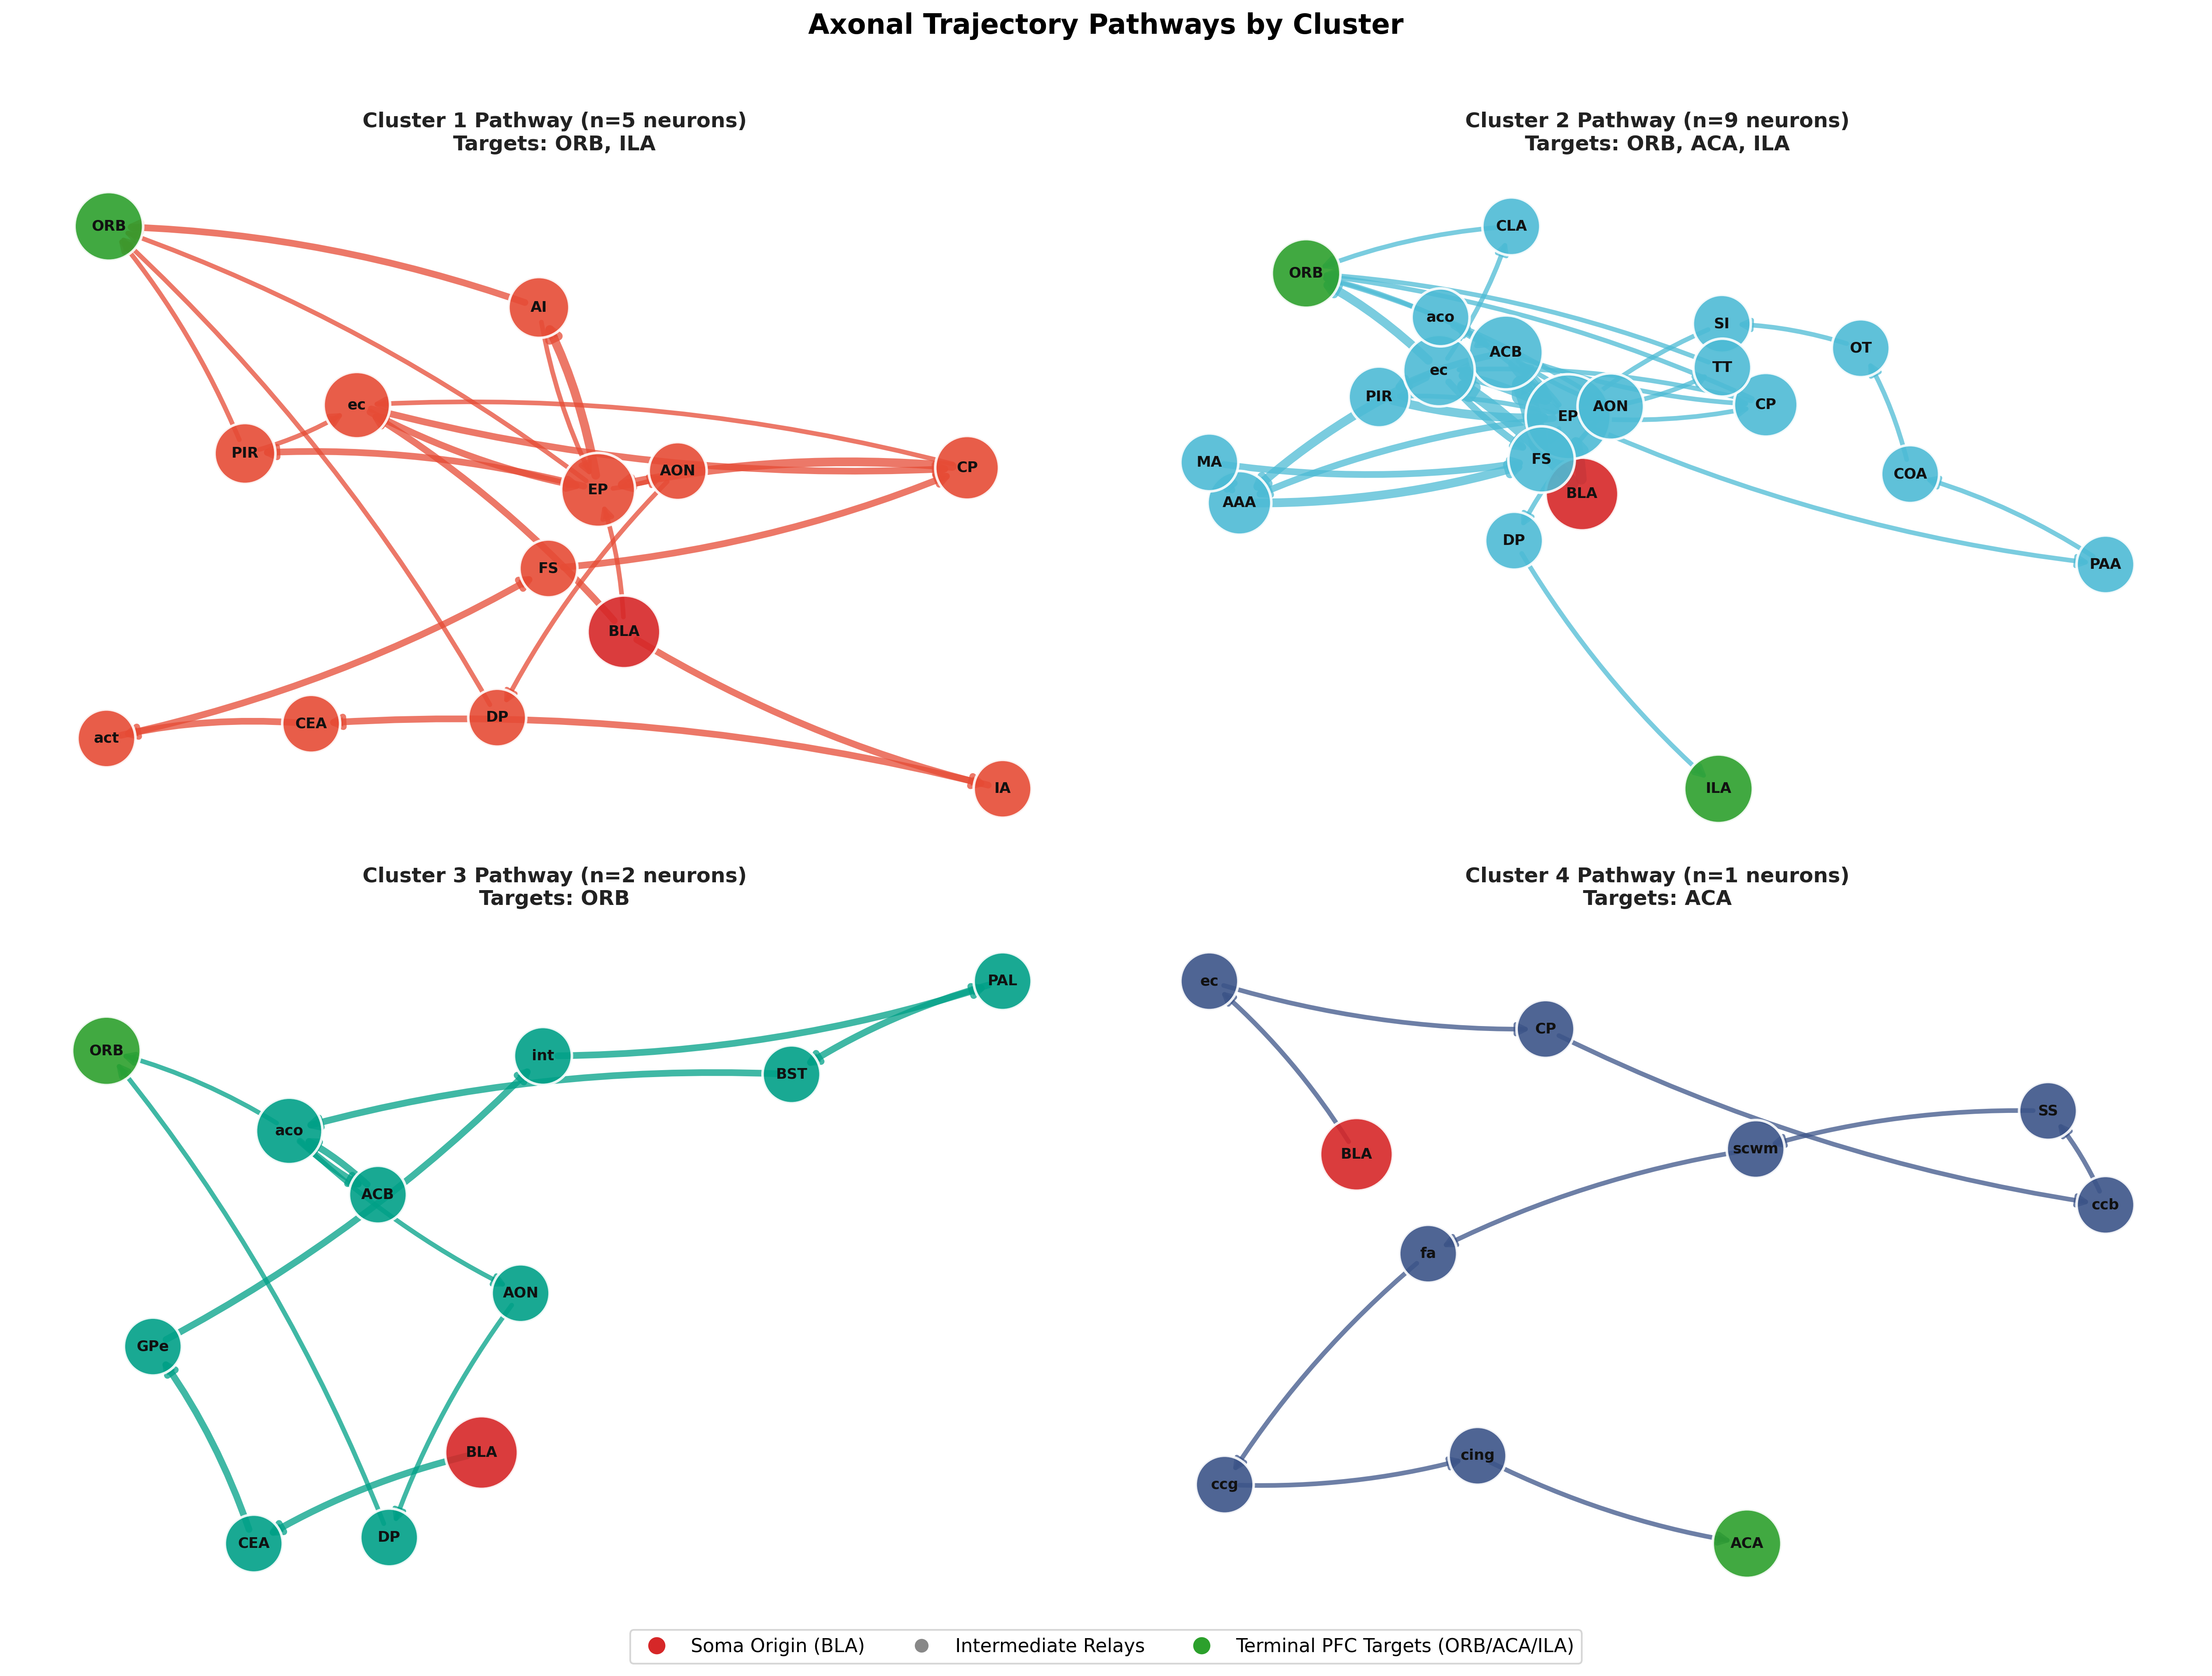

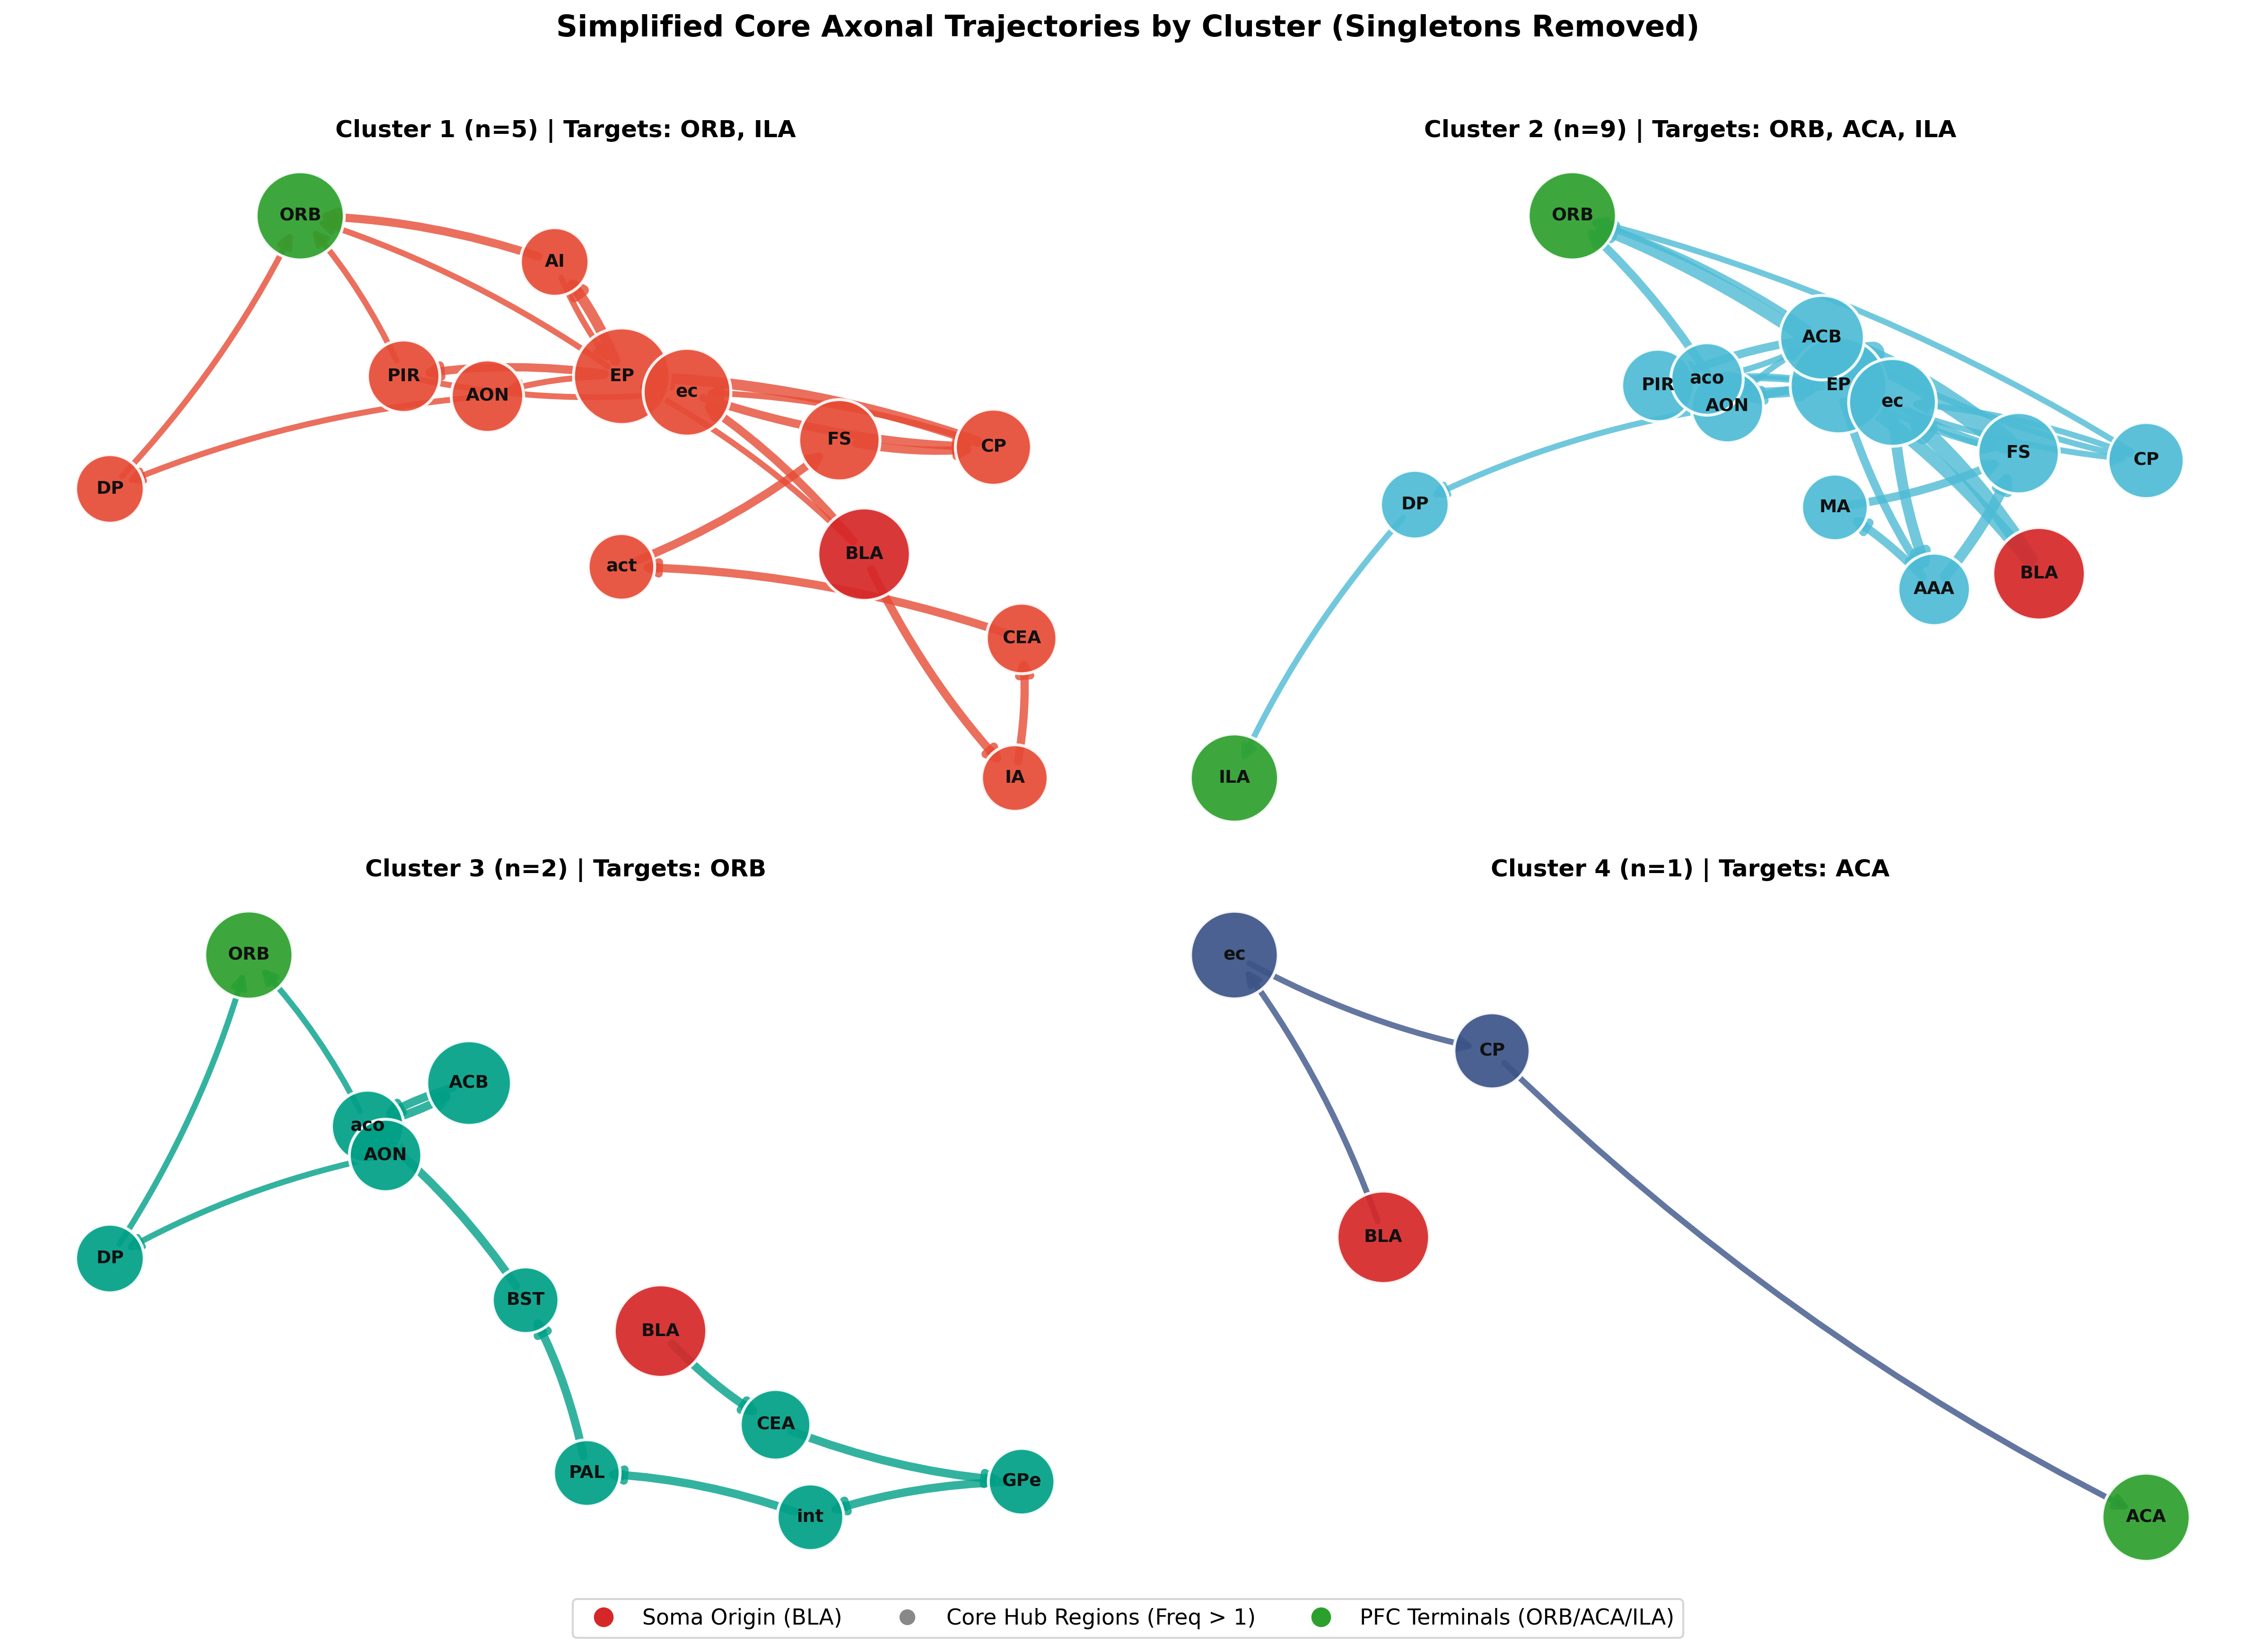

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import io
from collections import Counter

# 1. 载入数据
data = """neurons	cluster	Terminal_Group	Truncated_PFC_Trajectory
251034_001_Vglut1_PFC_0	1	ORB	BLA -> EP -> PIR -> ec -> EP -> AI -> ORB
251034_003_Vglut1_PFC_1	1	ORB	BLA -> ec -> CP -> EP -> ORB
251034_003_Vglut1_PFC_2	2	ORB	BLA -> EP -> FS -> ACB -> CP -> ORB
251034_004_Vglut1_PFC_3	2	ORB	BLA -> EP -> PIR -> EP -> PAA -> COA -> OT -> SI -> EP -> CP -> ec -> ORB
251034_010_Vglut1_PFC_4	2	ORB	BLA -> ec -> AAA -> FS -> ACB -> EP -> AON -> ORB
251034_010_Vglut1_PFC_5	2	ORB	BLA -> ec -> AAA -> FS -> ACB -> EP -> AON -> TT -> ORB
251034_010_Vglut1_PFC_6	2	ORB	BLA -> ec -> AAA -> FS -> ACB -> EP -> ec -> ORB
251039_020_Vglut1_PFC_7	2	ACA	BLA -> ec -> FS -> ACB -> EP -> ACB -> ORB
251039_020_Vglut1_PFC_8	2	ILA	BLA -> ec -> FS -> ACB -> EP -> aco -> ACB -> AON -> DP -> ILA
251039_021_Vglut1_PFC_10	3	ORB	BLA -> CEA -> GPe -> int -> PAL -> BST -> aco -> ACB -> aco -> AON -> DP -> ORB
251039_021_Vglut1_PFC_9	3	ORB	BLA -> CEA -> GPe -> int -> PAL -> BST -> aco -> ACB -> aco -> ORB
251039_029_Vglut1_PFC_11	4	ACA	BLA -> ec -> CP -> ccb -> SS -> scwm -> fa -> ccg -> cing -> ACA
251039_029_Vglut1_PFC_12	1	ORB	BLA -> IA -> CEA -> act -> FS -> CP -> EP -> AI -> ORB
251039_029_Vglut1_PFC_13	1	ORB	BLA -> IA -> CEA -> act -> FS -> CP -> EP -> PIR -> ORB
251039_029_Vglut1_PFC_14	2	ORB	BLA -> EP -> AAA -> MA -> FS -> ACB -> PIR -> EP -> ec -> ORB
251039_029_Vglut1_PFC_15	2	ORB	BLA -> EP -> AAA -> MA -> FS -> ACB -> PIR -> EP -> ec -> CLA -> ORB
251039_033_Vglut1_PFC_16	1	ILA	BLA -> ec -> CP -> ec -> EP -> AI -> EP -> AON -> DP -> ORB"""

df = pd.read_csv(io.StringIO(data), sep='\t')

# 2. 统计所有节点频次，筛选保留频次 > 1 的核心脑区（强制保留起点和终点靶区）
raw_paths = [[n.strip() for n in path.split('->') if n.strip()] for path in df['Truncated_PFC_Trajectory']]
all_nodes = [n for p in raw_paths for n in p]
counts = Counter(all_nodes)

# 过滤集合：出现 > 1 次，或为核心源/靶区
essential_nodes = {'BLA', 'ORB', 'ACA', 'ILA'}
kept_nodes = {k for k, v in counts.items() if v > 1}.union(essential_nodes)

# 3. 过滤精简各神经元路径（相邻重复节点自动去重，如 A -> A -> B 变为 A -> B）
def filter_and_compress(path):
    filtered = [n for n in path if n in kept_nodes]
    compressed = []
    for n in filtered:
        if not compressed or compressed[-1] != n:
            compressed.append(n)
    return compressed

df['Clean_Trajectory'] = [filter_and_compress(p) for p in raw_paths]

# 4. 构建全局骨干网络并锁定空间坐标
G_global = nx.DiGraph()
for path in df['Clean_Trajectory']:
    for u, v in zip(path[:-1], path[1:]):
        G_global.add_edge(u, v)

# 使用 spring 布局固定各节点位置（调大 k 值避免重叠）
global_pos = nx.spring_layout(G_global, k=1.4, seed=42, iterations=200)

# 5. 颜色配置
cluster_colors = {
    1: '#E64B35',  # 橙红
    2: '#4DBBD5',  # 天蓝
    3: '#00A087',  # 墨绿
    4: '#3C5488'   # 靛蓝
}
terminal_targets = {'ORB', 'ACA', 'ILA'}

# 6. 画布绘制 2x2 子图
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=300)
axes = axes.flatten()

for idx, cluster_id in enumerate(sorted(df['cluster'].unique())):
    ax = axes[idx]
    sub_df = df[df['cluster'] == cluster_id]
    
    # 统计该 Cluster 内部精简后的边频次
    G_sub = nx.DiGraph()
    for path in sub_df['Clean_Trajectory']:
        for u, v in zip(path[:-1], path[1:]):
            if G_sub.has_edge(u, v):
                G_sub[u][v]['weight'] += 1
            else:
                G_sub.add_edge(u, v, weight=1)
                
    sub_pos = {n: global_pos[n] for n in G_sub.nodes()}
    
    # 节点颜色与尺寸
    node_colors = []
    node_sizes = []
    for node in G_sub.nodes():
        if node == 'BLA':
            node_colors.append('#D62728')      # 起点: 鲜红
            node_sizes.append(2200)
        elif node in terminal_targets:
            node_colors.append('#2CA02C')      # 终点: 翠绿
            node_sizes.append(2000)
        else:
            node_colors.append(cluster_colors[cluster_id])
            node_sizes.append(1000 + counts[node] * 70)  # 节点大小由全局频次决定

    # 边宽
    edge_weights = [G_sub[u][v]['weight'] for u, v in G_sub.edges()]
    edge_widths = [1.8 + 1.2 * w for w in edge_weights]

    # 绘制
    nx.draw_networkx_nodes(G_sub, sub_pos, ax=ax, node_color=node_colors, 
                           node_size=node_sizes, alpha=0.92, edgecolors='white', linewidths=1.5)
    
    nx.draw_networkx_edges(G_sub, sub_pos, ax=ax, width=edge_widths, 
                           edge_color=cluster_colors[cluster_id], alpha=0.8,
                           arrows=True, arrowsize=14, arrowstyle='-|>', 
                           connectionstyle='arc3,rad=0.08')
    
    nx.draw_networkx_labels(G_sub, sub_pos, ax=ax, font_size=9, 
                            font_weight='bold', font_color='#111111')
    
    targets = ", ".join(sub_df['Terminal_Group'].unique())
    ax.set_title(f"Cluster {cluster_id} (n={len(sub_df)}) | Targets: {targets}", 
                 fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')

# 7. 全局图例
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Soma Origin (BLA)', 
               markerfacecolor='#D62728', markersize=11),
    plt.Line2D([0], [0], marker='o', color='w', label='Core Hub Regions (Freq > 1)', 
               markerfacecolor='#888888', markersize=9),
    plt.Line2D([0], [0], marker='o', color='w', label='PFC Terminals (ORB/ACA/ILA)', 
               markerfacecolor='#2CA02C', markersize=11)
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, frameon=True, fontsize=11, bbox_to_anchor=(0.5, 0.02))

plt.suptitle('Simplified Core Axonal Trajectories by Cluster (Singletons Removed)', 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

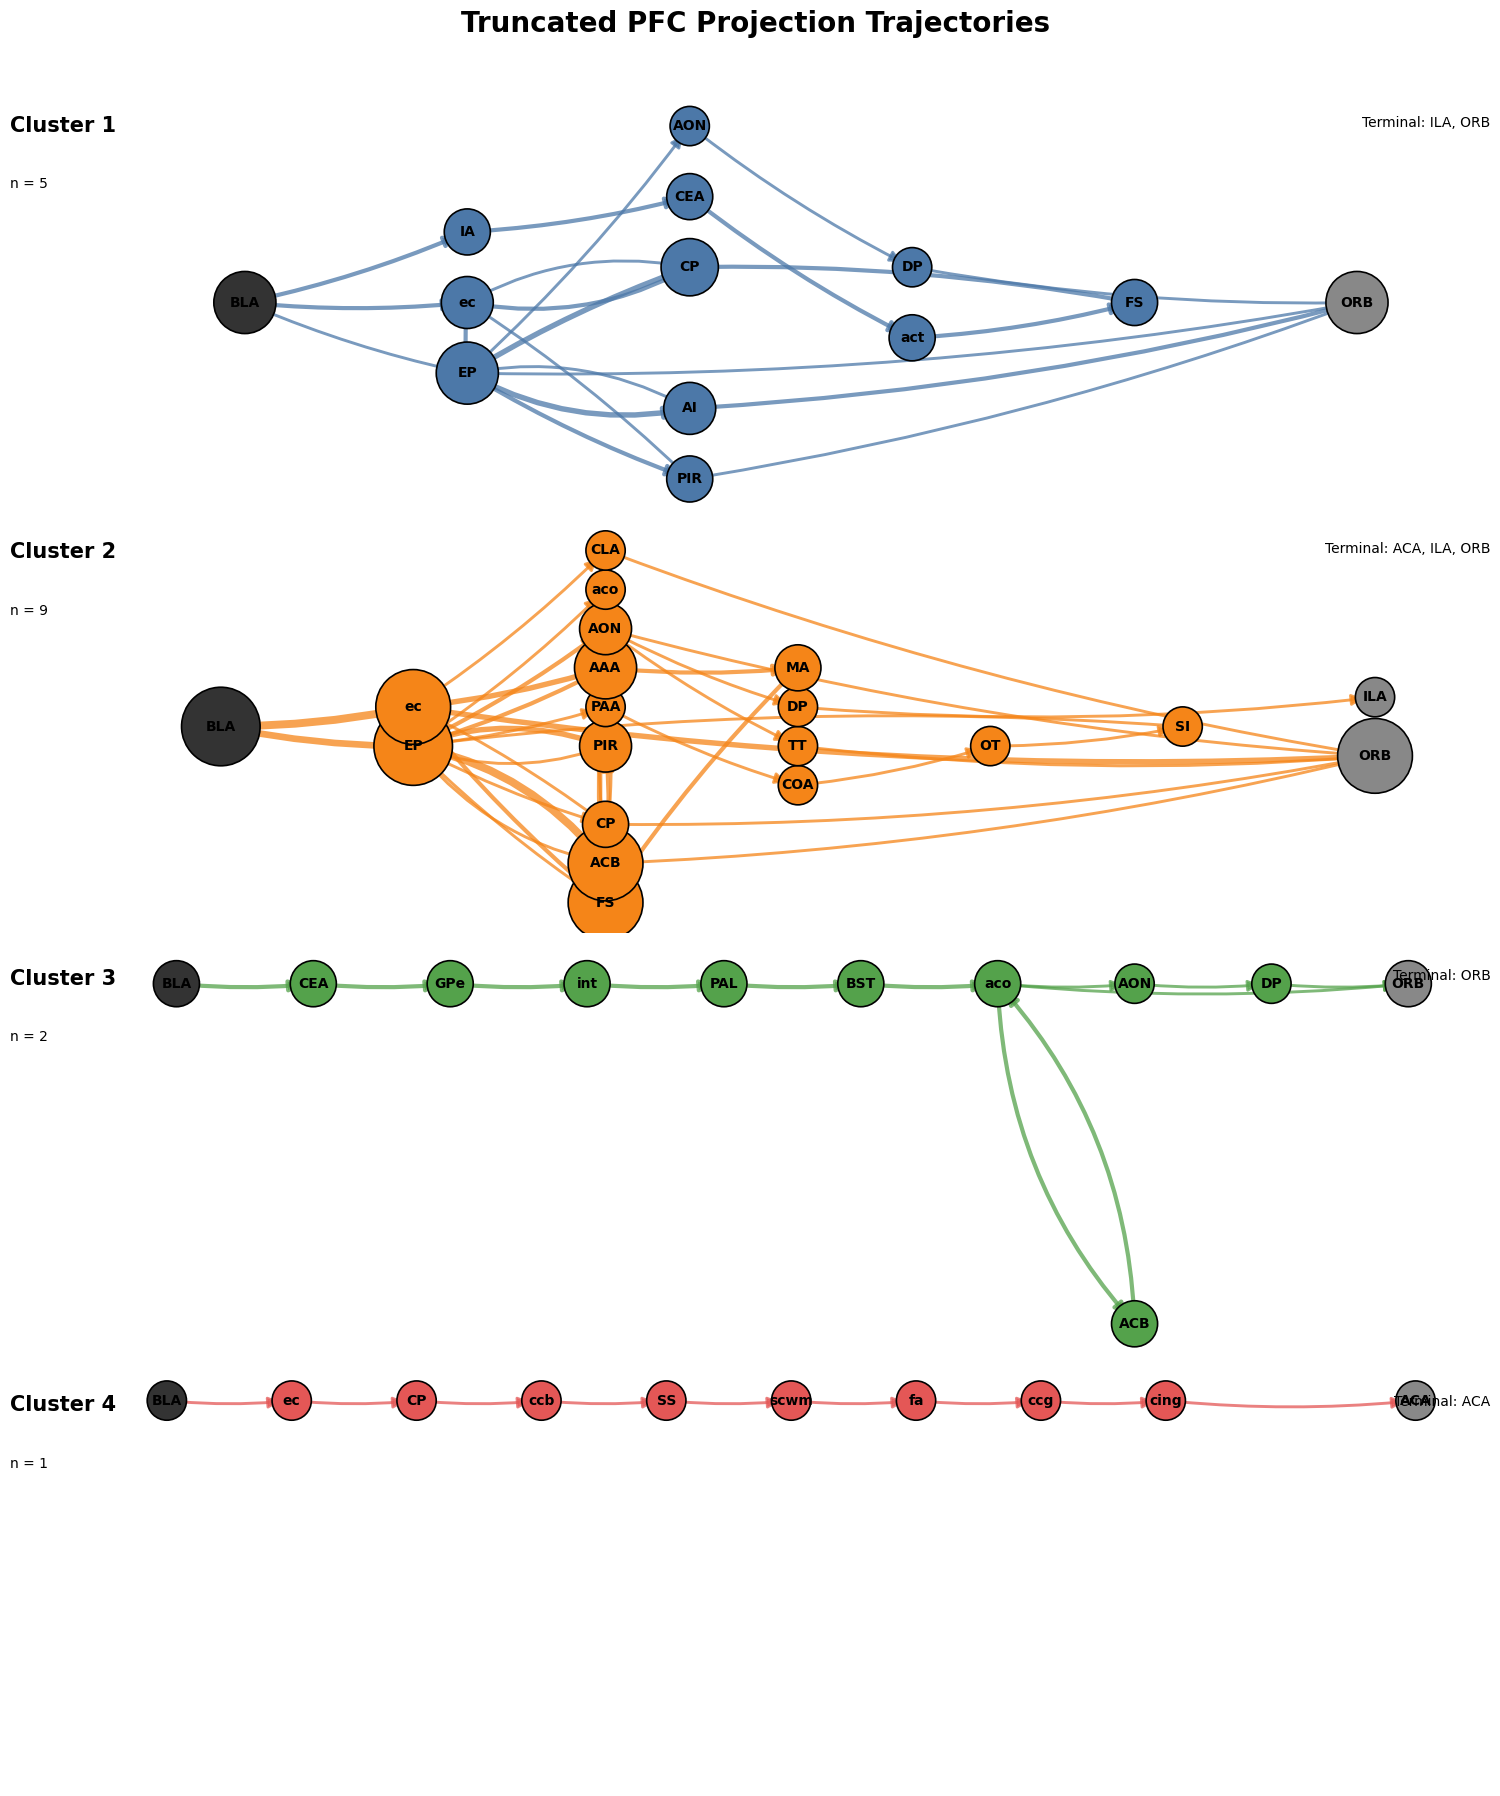

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# 1. 数据
# ============================================================

data = [
    ["251034_001_Vglut1_PFC_0", 1, "ORB",
     "BLA -> EP -> PIR -> ec -> EP -> AI -> ORB"],

    ["251034_003_Vglut1_PFC_1", 1, "ORB",
     "BLA -> ec -> CP -> EP -> ORB"],

    ["251034_003_Vglut1_PFC_2", 2, "ORB",
     "BLA -> EP -> FS -> ACB -> CP -> ORB"],

    ["251034_004_Vglut1_PFC_3", 2, "ORB",
     "BLA -> EP -> PIR -> EP -> PAA -> COA -> OT -> SI -> EP -> CP -> ec -> ORB"],

    ["251034_010_Vglut1_PFC_4", 2, "ORB",
     "BLA -> ec -> AAA -> FS -> ACB -> EP -> AON -> ORB"],

    ["251034_010_Vglut1_PFC_5", 2, "ORB",
     "BLA -> ec -> AAA -> FS -> ACB -> EP -> AON -> TT -> ORB"],

    ["251034_010_Vglut1_PFC_6", 2, "ORB",
     "BLA -> ec -> AAA -> FS -> ACB -> EP -> ec -> ORB"],

    ["251039_020_Vglut1_PFC_7", 2, "ACA",
     "BLA -> ec -> FS -> ACB -> EP -> ACB -> ORB"],

    ["251039_020_Vglut1_PFC_8", 2, "ILA",
     "BLA -> ec -> FS -> ACB -> EP -> aco -> ACB -> AON -> DP -> ILA"],

    ["251039_021_Vglut1_PFC_10", 3, "ORB",
     "BLA -> CEA -> GPe -> int -> PAL -> BST -> aco -> ACB -> aco -> AON -> DP -> ORB"],

    ["251039_021_Vglut1_PFC_9", 3, "ORB",
     "BLA -> CEA -> GPe -> int -> PAL -> BST -> aco -> ACB -> aco -> ORB"],

    ["251039_029_Vglut1_PFC_11", 4, "ACA",
     "BLA -> ec -> CP -> ccb -> SS -> scwm -> fa -> ccg -> cing -> ACA"],

    ["251039_029_Vglut1_PFC_12", 1, "ORB",
     "BLA -> IA -> CEA -> act -> FS -> CP -> EP -> AI -> ORB"],

    ["251039_029_Vglut1_PFC_13", 1, "ORB",
     "BLA -> IA -> CEA -> act -> FS -> CP -> EP -> PIR -> ORB"],

    ["251039_029_Vglut1_PFC_14", 2, "ORB",
     "BLA -> EP -> AAA -> MA -> FS -> ACB -> PIR -> EP -> ec -> ORB"],

    ["251039_029_Vglut1_PFC_15", 2, "ORB",
     "BLA -> EP -> AAA -> MA -> FS -> ACB -> PIR -> EP -> ec -> CLA -> ORB"],

    ["251039_033_Vglut1_PFC_16", 1, "ILA",
     "BLA -> ec -> CP -> ec -> EP -> AI -> EP -> AON -> DP -> ORB"],
]

df = pd.DataFrame(
    data,
    columns=[
        "neurons",
        "cluster",
        "Terminal_Group",
        "Truncated_PFC_Trajectory"
    ]
)


# ============================================================
# 2. 论文配色
# ============================================================

cluster_colors = {
    1: "#4C78A8",
    2: "#F58518",
    3: "#54A24B",
    4: "#E45756"
}


# ============================================================
# 3. 处理路径
# ============================================================

def parse_path(path_string):

    return [
        x.strip()
        for x in path_string.split("->")
        if x.strip()
    ]


# ============================================================
# 4. 为每个 Cluster 创建 NetworkX 图
# ============================================================

graphs = {}

for cluster in sorted(df["cluster"].unique()):

    sub_df = df[df["cluster"] == cluster]

    G = nx.MultiDiGraph()

    for _, row in sub_df.iterrows():

        path = parse_path(
            row["Truncated_PFC_Trajectory"]
        )

        # ----------------------------------------------------
        # 注意：
        # MultiDiGraph 可以保留同一条路径中的重复节点
        # ----------------------------------------------------

        for i in range(len(path) - 1):

            source = path[i]
            target = path[i + 1]

            G.add_edge(
                source,
                target,
                neuron=row["neurons"]
            )

    graphs[cluster] = G


# ============================================================
# 5. 计算节点出现频率
# ============================================================

def calculate_node_frequency(sub_df):

    frequency = {}

    for path_string in sub_df["Truncated_PFC_Trajectory"]:

        path = parse_path(path_string)

        for node in set(path):

            frequency[node] = frequency.get(node, 0) + 1

    return frequency


# ============================================================
# 6. 生成 4-panel Figure
# ============================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(15, 18)
)

for ax, cluster in zip(
    axes,
    sorted(df["cluster"].unique())
):

    sub_df = df[df["cluster"] == cluster]

    G = graphs[cluster]

    color = cluster_colors[cluster]

    # --------------------------------------------------------
    # 节点频率
    # --------------------------------------------------------

    node_frequency = calculate_node_frequency(
        sub_df
    )

    # --------------------------------------------------------
    # 确定节点
    # --------------------------------------------------------

    nodes = list(G.nodes())

    # --------------------------------------------------------
    # 分层布局
    # --------------------------------------------------------

    # 根据网络拓扑计算层级
    #
    # BLA = 0
    #
    # 其它节点根据从 BLA 的最短距离确定层级
    # --------------------------------------------------------

    layer = {}

    if "BLA" in G:

        distances = nx.single_source_shortest_path_length(
            nx.DiGraph(G),
            "BLA"
        )

        for node in nodes:

            if node in distances:
                layer[node] = distances[node]
            else:
                layer[node] = 0

    else:

        for node in nodes:
            layer[node] = 0


    # --------------------------------------------------------
    # 根据层级排列
    # --------------------------------------------------------

    layers = {}

    for node, l in layer.items():

        layers.setdefault(l, []).append(node)


    # --------------------------------------------------------
    # 手动控制 x 坐标
    # --------------------------------------------------------

    pos = {}

    max_layer = max(layers.keys())

    for l, layer_nodes in layers.items():

        # 防止所有节点重叠
        n = len(layer_nodes)

        if n == 1:

            ys = [0]

        else:

            ys = [
                (i - (n - 1) / 2)
                for i in range(n)
            ]

        for node, y in zip(layer_nodes, ys):

            pos[node] = (
                l * 2.5,
                y
            )


    # --------------------------------------------------------
    # 特殊处理终点
    # --------------------------------------------------------

    terminal_nodes = set(
        sub_df["Terminal_Group"]
    )

    terminal_nodes = [
        n for n in terminal_nodes
        if n in G.nodes
    ]

    # 把 Terminal Group 放到最右侧
    for i, node in enumerate(terminal_nodes):

        pos[node] = (
            max_layer * 2.5 + 2.5,
            (i - (len(terminal_nodes)-1)/2) * 1.5
        )


    # ========================================================
    # 绘制边
    # ========================================================

    edge_counter = {}

    for u, v in G.edges():

        key = (u, v)

        edge_counter[key] = (
            edge_counter.get(key, 0) + 1
        )


    # --------------------------------------------------------
    # 绘制不同曲率的边
    # --------------------------------------------------------

    for (u, v), weight in edge_counter.items():

        width = 1.2 + weight * 0.9

        # 如果是双向边，增加曲率
        if (v, u) in edge_counter:

            rad = 0.18

        else:

            rad = 0.05

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[(u, v)],
            ax=ax,
            width=width,
            edge_color=color,
            alpha=0.75,
            arrows=True,
            arrowsize=16,
            arrowstyle="-|>",
            connectionstyle=f"arc3,rad={rad}"
        )


    # ========================================================
    # 节点大小
    # ========================================================

    node_sizes = []

    for node in G.nodes():

        freq = node_frequency.get(
            node,
            1
        )

        node_sizes.append(
            500 + freq * 300
        )


    # ========================================================
    # 节点颜色
    # ========================================================

    node_colors = []

    for node in G.nodes():

        if node == "BLA":

            node_colors.append("#333333")

        elif node in terminal_nodes:

            node_colors.append("#888888")

        else:

            node_colors.append(color)


    # ========================================================
    # 绘制节点
    # ========================================================

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors="black",
        linewidths=1.2
    )


    # ========================================================
    # 节点标签
    # ========================================================

    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        font_size=10,
        font_weight="bold"
    )


    # ========================================================
    # Cluster 标题
    # ========================================================

    n_neurons = len(sub_df)

    ax.text(
        -0.04,
        0.95,
        f"Cluster {cluster}",
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="top"
    )

    ax.text(
        -0.04,
        0.80,
        f"n = {n_neurons}",
        transform=ax.transAxes,
        fontsize=10,
        va="top"
    )


    # ========================================================
    # 终点标注
    # ========================================================

    terminal_text = (
        "Terminal: "
        + ", ".join(
            sorted(
                sub_df["Terminal_Group"].unique()
            )
        )
    )

    ax.text(
        1.0,
        0.95,
        terminal_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10
    )


    # ========================================================
    # 美化
    # ========================================================

    ax.axis("off")

    ax.set_xlim(
        -2,
        max_layer * 2.5 + 4
    )


# ============================================================
# 7. 总标题
# ============================================================

fig.suptitle(
    "Truncated PFC Projection Trajectories",
    fontsize=20,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)


# ============================================================
# 8. 保存
# ============================================================

plt.savefig(
    "PFC_projection_clusters.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "PFC_projection_clusters.svg",
    bbox_inches="tight"
)

plt.savefig(
    "PFC_projection_clusters.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()